# Icon to Image Demo

This notebook demonstrates the `icon_to_image` package for rendering Font Awesome icons to images.

## Features

- Fast rendering using Rust's ab_glyph library
- Supersampling antialiasing for high-quality output
- PNG and WebP output formats
- Customizable colors, sizes, and positioning


In [1]:
from pathlib import Path

from IPython.display import display
from PIL import Image

from icon_to_image import IconRenderer

## Initialize the Renderer

The renderer uses embedded Font Awesome font files and CSS mappings, so no external files are needed.


In [2]:
# Initialize renderer with embedded Font Awesome assets (recommended)
renderer = IconRenderer()

print(f"Loaded {renderer.icon_count()} icons")

Loaded 2519 icons


## Basic Rendering

Render an icon with default settings (1024x1024, black on white).


In [3]:
def display_icon(img: Image.Image, size: tuple[int, int] = (128, 128)) -> None:
    """Helper to display a PIL Image in notebook at specified size."""
    img_resized = img.resize(size, Image.Resampling.LANCZOS)
    display(img_resized)

Rendered image: 512x512 pixels, mode=RGBA


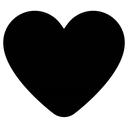

In [4]:
# Render a heart icon - render_icon() returns a PIL.Image directly
heart = renderer.render_icon("heart")
print(f"Rendered image: {heart.size[0]}x{heart.size[1]} pixels, mode={heart.mode}")
display_icon(heart)

## Custom Colors

Icons can be rendered with custom foreground and background colors using hex color codes.


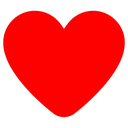

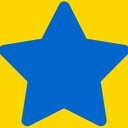

In [5]:
# Red heart on transparent background
red_heart = renderer.render_icon(
    "heart",
    icon_color="#FF0000",
    background_color=None,  # Transparent
)
display_icon(red_heart)

# Blue star on yellow background
blue_star = renderer.render_icon(
    "star",
    icon_color="#0066CC",
    background_color="#FFD700",
)
display_icon(blue_star)

## Brand Icons

Font Awesome includes brand icons for popular platforms and technologies.


Brand icons:
  github:


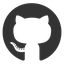

  python:


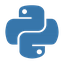

  rust:


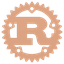

  duolingo:


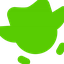

  apple:


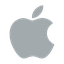

In [6]:
# Render some brand icons
brands = [
    ("github", "#333333"),
    ("python", "#3776AB"),
    ("rust", "#DEA584"),
    ("duolingo", "#58CC02"),
    ("apple", "#A2AAAD"),
]

print("Brand icons:")
for name, color in brands:
    img = renderer.render_icon(name, icon_color=color, background_color=None)
    print(f"  {name}:")
    display_icon(img, (64, 64))

## Font Styles

Font Awesome icons come in different styles:

- **Solid**: Filled icons (default for most icons)
- **Regular**: Outlined/hollow icons
- **Brands**: Company and brand logos (default for brand icons like "github")

You can explicitly specify a style using the `style` parameter.


Solid vs Regular styles:
  Solid heart:


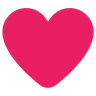

  Regular heart:


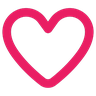


More solid vs regular comparisons:
  star (solid):


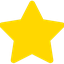

  star (regular):


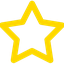

  circle (solid):


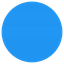

  circle (regular):


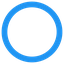

  bell (solid):


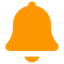

  bell (regular):


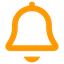

In [ ]:
# Compare solid vs regular styles for the same icon
# Many icons have both solid (filled) and regular (outlined) variants

print("Solid vs Regular styles:")

# Heart icon - solid (filled)
solid_heart = renderer.render_icon(
    "heart",
    canvas_width=256,
    canvas_height=256,
    icon_color="#E91E63",
    background_color=None,
    style="solid",  # Explicitly use solid style
)
print("  Solid heart:")
display_icon(solid_heart, (96, 96))

# Heart icon - regular (outlined)
regular_heart = renderer.render_icon(
    "heart",
    canvas_width=256,
    canvas_height=256,
    icon_color="#E91E63",
    background_color=None,
    style="regular",  # Use outlined version
)
print("  Regular heart:")
display_icon(regular_heart, (96, 96))

# More examples showing the difference
icons_with_styles = [
    ("star", "#FFD700"),
    ("circle", "#2196F3"),
    ("bell", "#FF9800"),
]

print("\nMore solid vs regular comparisons:")
for icon_name, color in icons_with_styles:
    print(f"  {icon_name} (solid):")
    solid = renderer.render_icon(
        icon_name, icon_color=color, background_color=None, style="solid"
    )
    display_icon(solid, (64, 64))
    print(f"  {icon_name} (regular):")
    regular = renderer.render_icon(
        icon_name, icon_color=color, background_color=None, style="regular"
    )
    display_icon(regular, (64, 64))

## Custom Sizes

You can control both the canvas size and the icon size independently.


Large (256x256):


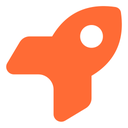

Small icon (128px) on 256px canvas:


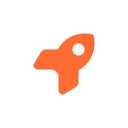

In [8]:
# Large icon filling the canvas
large = renderer.render_icon(
    "rocket",
    canvas_width=256,
    canvas_height=256,
    icon_color="#FF6B35",
)
print("Large (256x256):")
display_icon(large, (128, 128))

# Small icon with padding
small = renderer.render_icon(
    "rocket",
    canvas_width=256,
    canvas_height=256,
    icon_size=128,
    icon_color="#FF6B35",
)
print("Small icon (128px) on 256px canvas:")
display_icon(small, (128, 128))

## Positioning with Anchors

Icons can be positioned using horizontal and vertical anchors.


Icon positioning:
  Top-Left:


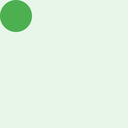

  Top-Right:


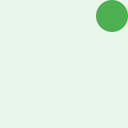

  Center:


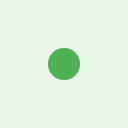

  Bottom-Left:


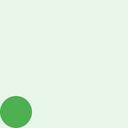

  Bottom-Right:


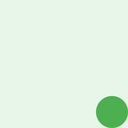

In [9]:
# Position icon at different corners
positions = [
    ("Top-Left", "left", "top"),
    ("Top-Right", "right", "top"),
    ("Center", "center", "center"),
    ("Bottom-Left", "left", "bottom"),
    ("Bottom-Right", "right", "bottom"),
]

print("Icon positioning:")
for name, h_anchor, v_anchor in positions:
    img = renderer.render_icon(
        "circle",
        canvas_width=256,
        canvas_height=256,
        icon_size=64,
        horizontal_anchor=h_anchor,
        vertical_anchor=v_anchor,
        icon_color="#4CAF50",
        background_color="#E8F5E9",
    )
    print(f"  {name}:")
    display_icon(img, (128, 128))

## Positioning with Offsets

Offsets allow fine-grained control over icon placement. Combined with anchors, you can create layouts like icons anchored to edges but with padding.


Icon anchored left with 20px margin:


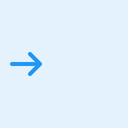

Icon anchored bottom-right with 16px padding:


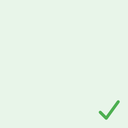

In [10]:
# Icon anchored to the left edge with horizontal margin (offset)
# This is useful for creating icons with consistent padding from edges
left_with_margin = renderer.render_icon(
    "arrow-right",
    canvas_width=256,
    canvas_height=256,
    icon_size=64,
    horizontal_anchor="left",
    vertical_anchor="center",
    offset_x=20,  # 20px margin from left edge
    icon_color="#2196F3",
    background_color="#E3F2FD",
)
print("Icon anchored left with 20px margin:")
display_icon(left_with_margin, (128, 128))

# Icon anchored to bottom-right with padding
bottom_right_padded = renderer.render_icon(
    "check",
    canvas_width=256,
    canvas_height=256,
    icon_size=48,
    horizontal_anchor="right",
    vertical_anchor="bottom",
    offset_x=-16,  # Negative offset moves left from right edge
    offset_y=-16,  # Negative offset moves up from bottom edge
    icon_color="#4CAF50",
    background_color="#E8F5E9",
)
print("Icon anchored bottom-right with 16px padding:")
display_icon(bottom_right_padded, (128, 128))

## Rotation

Icons can be rotated by specifying a rotation angle in degrees. Positive values rotate clockwise, negative values rotate counter-clockwise.


Rotation examples:
  0 degrees:


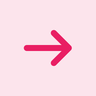

  45 degrees:


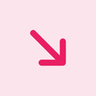

  90 degrees:


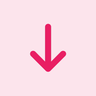

  180 degrees:


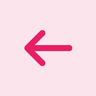

  -45 degrees:


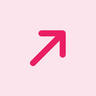


Rotated heart (30 degrees) on transparent background:


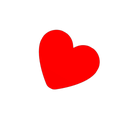

In [11]:
# Rotate an arrow icon by various angles
print("Rotation examples:")

rotations = [0, 45, 90, 180, -45]
for angle in rotations:
    img = renderer.render_icon(
        "arrow-right",
        canvas_width=256,
        canvas_height=256,
        icon_size=128,
        rotate=angle,
        icon_color="#E91E63",
        background_color="#FCE4EC",
    )
    print(f"  {angle} degrees:")
    display_icon(img, (96, 96))

# Rotated heart on transparent background
print("\nRotated heart (30 degrees) on transparent background:")
rotated_heart = renderer.render_icon(
    "heart",
    canvas_width=256,
    canvas_height=256,
    icon_size=128,
    rotate=30,
    icon_color="#FF0000",
    background_color=None,
)
display_icon(rotated_heart, (128, 128))

## render_icon() vs render_icon_bytes()

The `render_icon()` method returns a `PIL.Image` directly, which is convenient for image manipulation and display. The `render_icon_bytes()` method returns raw encoded bytes (PNG or WebP) and doesn't require Pillow.


render_icon() returns: PIL.Image.Image
Image size: (512, 512), mode: RGBA
Thumbnail size: (64, 64)


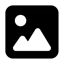


render_icon_bytes() returns: bytes
PNG size:  11,493 bytes
WebP size: 4,162 bytes
WebP is 36.2% of PNG size


In [ ]:
# render_icon() returns a PIL.Image directly
img = renderer.render_icon("image", canvas_width=512, canvas_height=512)
print(f"render_icon() returns: {type(img).__module__}.{type(img).__name__}")
print(f"Image size: {img.size}, mode: {img.mode}")

# You can manipulate the PIL.Image directly
thumbnail = img.copy()
thumbnail.thumbnail((64, 64))
print(f"Thumbnail size: {thumbnail.size}")
display(thumbnail)

# render_icon_bytes() returns raw encoded bytes (no Pillow required)
png_data = renderer.render_icon_bytes(
    "image", canvas_width=512, canvas_height=512, output_format="png"
)
webp_data = renderer.render_icon_bytes(
    "image", canvas_width=512, canvas_height=512, output_format="webp"
)

print(f"\nrender_icon_bytes() returns: {type(png_data).__name__}")
print(f"PNG size:  {len(png_data):,} bytes")
print(f"WebP size: {len(webp_data):,} bytes")
print(f"WebP is {100 * len(webp_data) / len(png_data):.1f}% of PNG size")

## Save to File

Icons can be saved directly to disk using `save_icon()`, or you can save a PIL.Image using its `save()` method.


In [ ]:
# Save icons to files
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# Method 1: Use save_icon() - fast, writes directly from Rust
renderer.save_icon(
    "check-circle",
    str(output_dir / "check.png"),
    icon_color="#4CAF50",
    supersample=1,
    background_color="#FFFFFF",
)
print(f"Saved: {output_dir / 'check.png'}")

# Method 2: Use render_icon() and PIL's save() for more control
img = renderer.render_icon(
    "times-circle", icon_color="#F44336", background_color="#FFFFFF"
)
img.save(output_dir / "times.webp")
print(f"Saved: {output_dir / 'times.webp'}")

# Method 3: Use render_icon_bytes() and write manually
png_data = renderer.render_icon_bytes("star", icon_color="#FFD700")
(output_dir / "star.png").write_bytes(png_data)
print(f"Saved: {output_dir / 'star.png'}")

Saved: output/check.png
Saved: output/times.webp
Saved: output/star.png


## List Available Icons

You can query the renderer for available icons.


In [14]:
# Get all icon names
all_icons = renderer.list_icons()
print(f"Total icons: {len(all_icons)}")

# Find icons matching a pattern
arrow_icons = [name for name in all_icons if "arrow" in name]
print(f"\nArrow icons ({len(arrow_icons)}): {arrow_icons[:10]}...")

# Check if specific icons exist
icons_to_check = ["heart", "star", "github", "nonexistent"]
print("\nIcon availability:")
for icon in icons_to_check:
    exists = renderer.has_icon(icon)
    print(f"  {icon}: {'Yes' if exists else 'No'}")

Total icons: 2519

Arrow icons (115): ['arrow-right-long', 'cloud-arrow-up', 'long-arrow-up', 'arrows-h', 'arrow-turn-down', 'arrow-rotate-backward', 'arrow-up-long', 'arrow-alt-circle-left', 'arrow-alt-circle-right', 'long-arrow-right']...

Icon availability:
  heart: Yes
  star: Yes
  github: Yes
  nonexistent: No


## Performance

The Rust backend provides fast rendering performance.


In [15]:
import time

# Benchmark rendering 100 icons
icons_to_render = all_icons[:100]

start = time.perf_counter()
for icon_name in icons_to_render:
    _ = renderer.render_icon(
        icon_name,
    )
elapsed = time.perf_counter() - start

print(f"Rendered {len(icons_to_render)} icons in {elapsed:.3f}s")
print(f"Average: {1000 * elapsed / len(icons_to_render):.2f}ms per icon")

Rendered 100 icons in 0.740s
Average: 7.40ms per icon
